## Bitcoin Price Prediction using LSTM Model
This notebook aims to build a cryptocurrency price prediction model (Bitcoin) using an LSTM model by retrieving historical price data from CoinGecko. The goal is to evaluate the model's performance before deploying it to Streamlit.

Steps:
1. Import the required libraries.
2. Retrieve bitcoin price data from CoinGecko.
3. Preprocess the data (scaling and sequence creation).
4. Build and train the LSTM model.
5. Evaluate the model on the test data.
6. Predict prices for the next 30 days.
7. Save the model for deployment.

In [6]:
import pandas as pd
import numpy as np
import requests
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math
from datetime import timedelta
import logging
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Retrieve price data from CoinGecko

def get_crypto_data(symbol, days):
    try:
        url = f"https://api.coingecko.com/api/v3/coins/{symbol}/market_chart?vs_currency=usd&days={days}"
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
        if 'prices' not in data or 'total_volumes' not in data:
            logging.error("Data harga atau volume tidak ditemukan.")
            return None
        df = pd.DataFrame({
            'timestamp': pd.to_datetime([p[0] for p in data['prices']], unit='ms'),
            'price': [p[1] for p in data['prices']],
            'volume': [v[1] for v in data['total_volumes']]
        })
        df.set_index('timestamp', inplace=True)
        df = df.dropna()
        return df
    except requests.RequestException as e:
        logging.error(f"Error fetching price data: {str(e)}")
        return None

symbol='bitcoin'
days=365
price_data = get_crypto_data(symbol, days)
if price_data is None:
    raise ValueError("Gagal mengambil data harga.")
print(f"Data harga diambil: {len(price_data)} hari, NaN count: {price_data['price'].isna().sum()}")

Data harga diambil: 366 hari, NaN count: 0


In [ ]:
# Scaling
price_scaler = MinMaxScaler()
scaled_data = price_scaler.fit_transform(price_data[['price']])

In [ ]:
# Build and train the LSTM model
def create_dataset(data, time_step=50):
    X, Y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), :])
        Y.append(data[i + time_step, 0])  # Hanya prediksi harga
    return np.array(X), np.array(Y)

time_step = 50
X, Y = create_dataset(scaled_data, time_step)
if np.any(np.isnan(X)) or np.any(np.isnan(Y)):
    raise ValueError("Dataset mengandung NaN. Periksa data input.")
print(f"Ukuran dataset X: {X.shape}, Y: {Y.shape}")

Ukuran dataset X: (316, 50, 1), Y: (316,)


In [ ]:
# split dataset
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

Epoch 1/100


d:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - loss: 0.2470 - val_loss: 0.0037
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0237 - val_loss: 0.0833
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0229 - val_loss: 0.0033
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0156 - val_loss: 0.0085
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0227 - val_loss: 0.0035
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0100 - val_loss: 0.0154
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0087 - val_loss: 0.0251
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0097 - val_loss: 0.0106
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0055 - val_loss: 0.0044
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0072 - val_loss: 0.0045
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0063 - val_loss: 0.0076
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0053 - val_loss: 0.0120


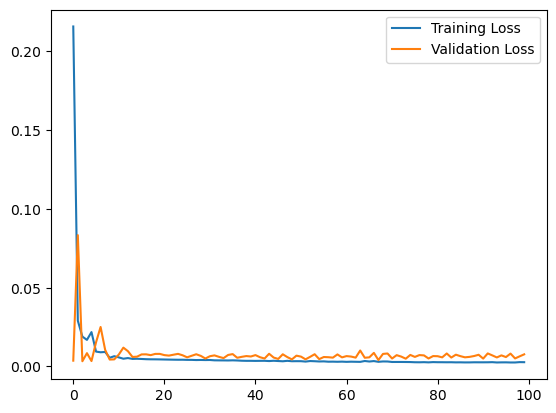

In [ ]:
model = Sequential()
model.add(LSTM(100, return_sequences=True, input_shape=(time_step, 1)))  # Tingkatkan unit
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

early_stopping = EarlyStopping(monitor='loss', patience=10)  # Tingkatkan patience
history = model.fit(X_train, Y_train, epochs=100, batch_size=64,  # Tingkatkan epochs dan batch_size
                    validation_split=0.2, callbacks=[early_stopping], verbose=1)
model.save('crypto_lstm_model.h5')

# Plot loss for debugging
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

RMSE: 2829.074442443319


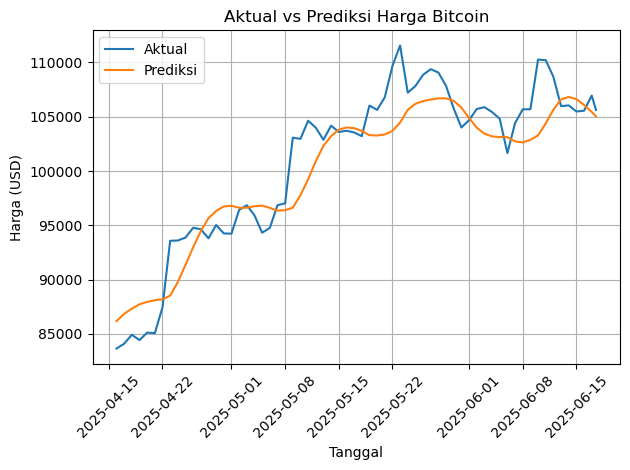

In [ ]:
logging.info("Memulai evaluasi model...")

# Prediction
test_predict = model.predict(X_test, verbose=0)
test_predict = test_predict.reshape(-1, 1)  # Pastikan bentuk sesuai

# Inverse transform
Y_test_inv = price_scaler.inverse_transform(Y_test.reshape(-1, 1))
test_predict_inv = price_scaler.inverse_transform(test_predict)

# RMSE Evaluation
rmse = math.sqrt(mean_squared_error(Y_test_inv, test_predict_inv))
print(f"RMSE: {rmse}")

# Visualization
dates = price_data.index[-len(Y_test_inv):] 
plt.figure()
plt.plot(dates, Y_test_inv, label='Aktual')
plt.plot(dates, test_predict_inv, label='Prediksi')
plt.legend()
plt.title('Aktual vs Prediksi Harga Bitcoin')
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD)')
plt.grid(True)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

logging.info(f"Evaluasi selesai dengan RMSE: {rmse}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━

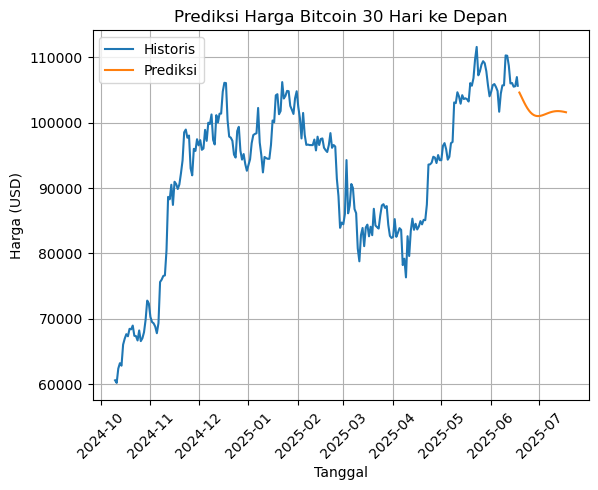

In [ ]:
# Predict prices for the next 30 days
last_sequence = scaled_data[-time_step:, :]
last_sequence = last_sequence.reshape(1, time_step, 1)

predictions = []
current_input = last_sequence.copy()
for _ in range(30):
    next_pred = model.predict(current_input)[0, 0]
    predictions.append(next_pred)
    next_input = np.array([[[next_pred]]])
    current_input = np.append(current_input[:, 1:, :], next_input, axis=1)

# Inverse transform prediction
predictions_inv = price_scaler.inverse_transform(np.array(predictions).reshape(-1,1))

# Plot
future_dates = [price_data.index[-1] + timedelta(days=i+1) for i in range(30)]
plt.figure()
plt.plot(price_data.index[-252:], price_data['price'].values[-252:], label='Historis')
plt.plot(future_dates, predictions_inv, label='Prediksi')
plt.legend()
plt.title('Prediksi Harga Bitcoin 30 Hari ke Depan')
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Conclusion
This notebook has built and tested an LSTM model to predict Bitcoin prices using price data from CoinGecko. The model has been evaluated with RMSE and can predict prices for the next 30 days.